<h1 style="background: linear-gradient(to right, #ff6b6b, #4ecdc4); 
           color: white; 
           padding: 20px; 
           border-radius: 10px; 
           text-align: center; 
           font-family: Arial, sans-serif; 
           text-shadow: 2px 2px 4px rgba(0,0,0,0.5);">
  Introduction to Quantization
</h1>

In this notebook we will learn about quantization: why numeric precision drives a model's memory and speed, how to implement quantization and dequantization by hand, and how the 4 bit format QLoRA relies on actually works.

This is the first of two notebooks that build fine tuning up from first principles:

- [Quantization](./01_quantization.ipynb) (this notebook)
- [LoRA and QLoRA](./02_lora_and_qlora.ipynb)

Once you have seen what these techniques actually do, you can go use [Crusoe's Serverless Fine-Tuning](../02-serverless-fine-tuning-pii-redaction/) and trust what it is doing for you under the hood, instead of treating it as a black box.

By the end of this notebook you will:

1. Know why numeric precision drives the memory and speed of a model,
2. Implement quantization and dequantization by hand and measure the error it introduces,
3. See why quantization granularity, per tensor versus per channel, matters for real transformer weights,
4. Load a real Hugging Face model in 4 bit and measure the memory it actually saves.

<div align="center"><img src="assets/quantization_formats.svg" alt="FP32, FP16/BF16, INT8, and INT4/NF4 blocks shrinking in size" width="750"/></div>

## `Step 1`: Why precision matters

Every weight and activation in a neural network is stored as a number in some numeric format, and the format decides how many bytes that number costs.

| Format | Bits | Bytes per value | Where it shows up |
|---|---|---|---|
| FP32 | 32 | 4 | Classic full precision training |
| FP16 / BF16 | 16 | 2 | Default for training and inference today |
| FP8 | 8 | 1 | Newer accelerators, some inference stacks |
| INT8 | 8 | 1 | Post training quantization, LLM.int8() |
| INT4 / NF4 | 4 | 0.5 | QLoRA, the most aggressive format in common use |

Model size in bytes is `number_of_parameters * bytes_per_value`. A 7 billion parameter model is roughly 28 GB in FP32, 14 GB in FP16 or BF16, 7 GB in INT8, and about 3.5 GB in 4 bit. That difference decides whether a model fits on one GPU, needs several, or does not fit at all.

Precision affects speed too, not only memory. Modern GPUs can move data in and out of their compute units far faster than the compute units can be kept fed for large matrix multiplications at full precision, so a lot of LLM inference is memory bandwidth bound. Reading half or a quarter as many bytes per weight makes a model both smaller and faster to run.

See the Hugging Face [quantization overview](https://huggingface.co/docs/transformers/main/en/quantization/overview) and the [bitsandbytes documentation](https://huggingface.co/docs/bitsandbytes/main/en/index) for the library this notebook uses later on.

### `BF16` versus `FP16`

Both FP16 and BF16 use 16 bits, but they split those bits differently between the exponent (which sets the range of representable magnitudes) and the mantissa (which sets precision within that range). A useful way to tell precision and range apart: `1.12547e-06` is more precise than `1.12000e-06` (more significant digits), while `3.112e-17` covers a wider range than `1.968e-05` (a much larger exponent), regardless of which one is more precise.

FP16 spends more bits on the mantissa and fewer on the exponent, so it is more precise but overflows above about 65,504 and underflows small values to exactly zero. BF16 mirrors FP32's exponent, giving it FP32's huge range at the cost of noticeably less precision per value.

That is why BF16 is the default for training large models today: intermediate values that overflow FP16 into `inf`, or underflow it to `0.0`, stay finite and non-zero in BF16. [`torch.finfo`](https://docs.pytorch.org/docs/stable/type_info.html) reports the exact numbers for any dtype.

In [1]:
import torch

for dtype in [torch.float32, torch.bfloat16, torch.float16]:
    info = torch.finfo(dtype)
    print(dtype, "| max:", info.max, "| eps:", info.eps)

large_values = torch.tensor([70000.0, 100000.0, 50000.0])
print("\nOverflow example")
print("original:", large_values.tolist())
print("as BF16 :", large_values.to(torch.bfloat16).tolist())
print("as FP16 :", large_values.to(torch.float16).tolist())

tiny_values = torch.tensor([1e-8, 3e-8, 8e-8])
print("\nUnderflow example")
print("original:", tiny_values.tolist())
print("as BF16 :", tiny_values.to(torch.bfloat16).tolist())
print("as FP16 :", tiny_values.to(torch.float16).tolist())

torch.float32 | max: 3.4028234663852886e+38 | eps: 1.1920928955078125e-07
torch.bfloat16 | max: 3.3895313892515355e+38 | eps: 0.0078125
torch.float16 | max: 65504.0 | eps: 0.0009765625

Overflow example
original: [70000.0, 100000.0, 50000.0]
as BF16 : [70144.0, 99840.0, 49920.0]
as FP16 : [inf, inf, 49984.0]

Underflow example
original: [9.99999993922529e-09, 2.999999892949745e-08, 7.999999951380232e-08]
as BF16 : [1.0011717677116394e-08, 3.003515303134918e-08, 8.009374141693115e-08]
as FP16 : [0.0, 5.960464477539063e-08, 5.960464477539063e-08]


### `mixed precision` is not `quantization`



It is easy to conflate the two, since both involve lower precision numbers, but they solve different problems. Quantization permanently stores weights in fewer bits to shrink memory. Mixed precision keeps weights in full precision (FP32) in memory, and only casts them to a lower precision temporarily during computation, purely for speed. [`torch.autocast`](https://docs.pytorch.org/docs/stable/amp.html) is the standard way to do this: wrap a forward pass in it and PyTorch handles the casting for you, without you touching the model's stored weights at all.

In [2]:
import time
import torch.nn as nn

class TinyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.a = nn.Linear(2000, 2000)
        self.b = nn.Linear(2000, 2000)

    def forward(self, x):
        return self.b(self.a(x))

def timeit_forward(model, x, n=200):
    torch.cuda.synchronize()
    start = time.time()
    for _ in range(n):
        model(x)
    torch.cuda.synchronize()
    return (time.time() - start) / n * 1e6

model = TinyModel().to("cuda")                      # weights stay FP32 the whole time
x = torch.randn(2000, 2000, device="cuda")

print(f"Plain FP32 forward pass: {timeit_forward(model, x):.0f} microseconds")

with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
    print(f"FP32 model under BF16 autocast: {timeit_forward(model, x):.0f} microseconds")

print(f"Model weights are still: {model.a.weight.dtype}")

Plain FP32 forward pass: 1221 microseconds
FP32 model under BF16 autocast: 763 microseconds
Model weights are still: torch.float32


The forward pass gets noticeably faster, but the model's weights never left FP32. This is exactly why every `BitsAndBytesConfig` later in this notebook (and in the next one) sets `bnb_4bit_compute_dtype=torch.bfloat16`: the frozen weights are stored quantized for memory, and BF16 is only the dtype computation happens in, the mixed precision trick layered on top of quantization, not a replacement for it.

## `Step 2`: What quantization actually does

Quantization maps a wide range of real valued numbers onto a small set of discrete integer levels, then keeps a scale (and sometimes an offset called the zero point) to map back. The general, affine form is:

```
quantize:   q = round(x / scale) + zero_point
dequantize: x_hat = scale * (q - zero_point)
```

Weights tend to be roughly symmetric around zero, so the simpler symmetric case drops the zero point entirely:

```
scale = max(abs(x)) / qmax
q = clip(round(x / scale), -qmax, qmax)
```

This is called absmax quantization, and it is the scheme [bitsandbytes](https://huggingface.co/docs/bitsandbytes/main/en/index) uses for LLM weights. `scale` is one floating point number computed from the data itself. It has to be stored alongside the integers, but it is one number for potentially thousands of them, so the overhead is tiny.

Two things decide how much error this introduces:

- **Number of levels.** INT8 gives 256 levels, INT4 gives 16. Fewer levels means coarser rounding.
- **Granularity.** One scale for a whole tensor (per tensor) is cheap to store but fragile. One scale per row or column (per channel), or per small group of values (per block, what NF4 uses further down), is more accurate because it isolates outliers instead of letting them stretch the whole range.

Outliers matter a lot in real transformers. [Dettmers](https://arxiv.org/abs/2208.07339) found that a small number of feature dimensions in large models carry disproportionately large activations, and quantizing those naively with one per tensor scale crushes the resolution for every other value in the tensor (see [LLM.int8(), 2022](https://arxiv.org/abs/2208.07339)). Later work such as [GPTQ](https://arxiv.org/abs/2210.17323) and [AWQ](https://arxiv.org/abs/2306.00978) goes further, using a small amount of calibration data to decide which weights matter most before quantizing them.

### Seeing it happen: snapping to a grid

Before quantizing a real weight matrix, look at what quantization does to any batch of continuous values: each one gets sorted into the nearest of a small, fixed set of bins, and only the bin it landed in gets remembered. Every value inside the same bin becomes indistinguishable once dequantized.

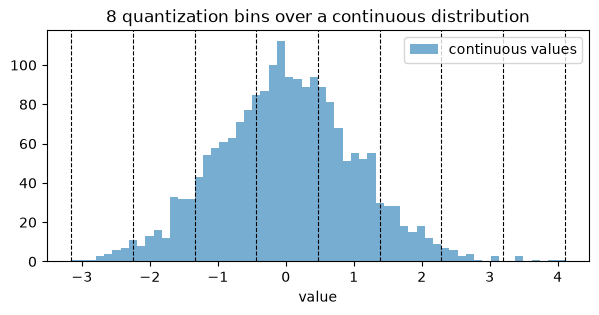

In [3]:
import matplotlib.pyplot as plt

torch.manual_seed(0)
demo_values = torch.randn(2000)
n_bins = 8
bin_edges = torch.linspace(demo_values.min(), demo_values.max(), n_bins + 1)

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(demo_values, bins=60, color="tab:blue", alpha=0.6, label="continuous values")
for edge in bin_edges:
    ax.axvline(edge.item(), color="black", linewidth=0.8, linestyle="--")
ax.set_title(f"{n_bins} quantization bins over a continuous distribution")
ax.set_xlabel("value")
ax.legend()
plt.show()

### Quantizing a weight matrix by hand

The cell below implements the symmetric absmax scheme above from scratch: quantize a matrix of made up weights to INT8, dequantize it, and measure how much error that round trip introduces.

In [4]:
import torch

torch.manual_seed(0)

def quantize_absmax_int8(x):
    scale = x.abs().max() / 127
    q = torch.clamp(torch.round(x / scale), -127, 127).to(torch.int8)
    return q, scale

def dequantize(q, scale):
    return q.to(torch.float32) * scale

weight = torch.randn(768, 768)
q, scale = quantize_absmax_int8(weight)
restored = dequantize(q, scale)

error = (weight - restored).pow(2).mean().item()
print("Original size (in bytes):", weight.numel() * weight.element_size())
print("Quantized size (in bytes):", q.numel() * q.element_size())
print("Mean Squared Error:", error)

Original size (in bytes): 2359296
Quantized size (in bytes): 589824
Mean Squared Error: 0.00011198947322554886


### Granularity: `per tensor` versus `per channel`

Now let's see, what happens when one row of the matrix is an outlier, much larger in magnitude than the rest, similar to the outlier feature dimensions found in real transformers. With a single scale for the whole tensor, that one row forces `scale` up for every other value too.

In [5]:
def quantize_per_channel(x):
    scale = x.abs().amax(dim=1, keepdim=True) / 127
    q = torch.clamp(torch.round(x / scale), -127, 127).to(torch.int8)
    return q, scale

def dequantize_per_channel(q, scale):
    return q.to(torch.float32) * scale

weight_with_outlier = weight.clone()
weight_with_outlier[3] *= 50                                # one row now behaves like an outlier channel

q_tensor, scale_tensor = quantize_absmax_int8(weight_with_outlier)
q_channel, scale_channel = quantize_per_channel(weight_with_outlier)

error_tensor = (weight_with_outlier - dequantize(q_tensor, scale_tensor)).pow(2).mean().item()
error_channel = (weight_with_outlier - dequantize_per_channel(q_channel, scale_channel)).pow(2).mean().item()

print("per tensor scale, mean squared error:", error_tensor)
print("per channel scale, mean squared error:", error_channel)

per tensor scale, mean squared error: 0.21627412736415863
per channel scale, mean squared error: 0.00033763001556508243


One outlier row barely affects the per channel result, because that row gets its own scale, but it inflates the error for every other row under a single per tensor scale. This is exactly why production quantization schemes use per channel or per block scales instead of one scale for an entire weight matrix.

### How many bits do you actually need?

Generalize the `absmax` scheme to an arbitrary bit width and see how the error grows as bits are taken away.

<div align="center"><img src="assets/quantization_bins.gif" alt="Animated histogram showing quantization bins refining from 1 bit to 8 bits" width="550"/></div>

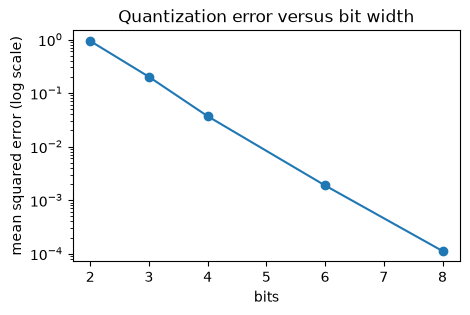

In [6]:
def quantize_absmax(x, n_bits):
    qmax = 2 ** (n_bits - 1) - 1
    scale = x.abs().max() / qmax
    q = torch.clamp(torch.round(x / scale), -qmax, qmax)
    return q, scale

bit_widths = [2, 3, 4, 6, 8]
errors = []
for n_bits in bit_widths:
    q, scale = quantize_absmax(weight, n_bits)
    restored = dequantize(q, scale)
    errors.append((weight - restored).pow(2).mean().item())

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(bit_widths, errors, marker="o")
ax.set_yscale("log")
ax.set_xlabel("bits")
ax.set_ylabel("mean squared error (log scale)")
ax.set_title("Quantization error versus bit width")
plt.show()

Error grows smoothly as bits are removed, but the absolute numbers matter: dropping from 8 bits to 4 bits makes the error roughly 300 times larger under this plain, uniformly spaced scheme. Going as low as 4 bits without that kind of accuracy hit needs a smarter placement of levels than evenly spaced ones, which is exactly what NF4 provides.

## `Step 3`: 4 bit and the NF4 format

INT4 gives only 16 levels, and if they are spaced uniformly across the range like INT8's levels are, most of them go to waste: neural network weights cluster tightly around zero in a roughly bell shaped distribution, so a uniform grid spends most of its 16 levels on rare large values and very few near zero, where most of the actual weight mass sits.

QLoRA's answer is **NF4 (Normal Float 4)**: instead of uniform spacing, its 16 levels sit at the quantiles of a standard normal distribution, so more levels land where the weights actually are. QLoRA also adds **double quantization**: blockwise quantization (used by both INT4 and NF4) stores one small scale constant per block, for example every 64 values, and across a whole model those constants add up to real memory. Double quantization quantizes the constants themselves in a second, coarser pass, saving roughly another 0.4 bits per parameter. Both ideas come from the [QLoRA paper](https://arxiv.org/abs/2305.14314) (see section 3 for the details), and the implementation lives in [bitsandbytes' Linear4bit](https://huggingface.co/docs/bitsandbytes/main/en/reference/nn/linear4bit) layer.

### Seeing NF4's levels

`bitsandbytes` ships both `LinearFP4` (a uniform 4 bit floating point format) and `LinearNF4` layers. Loading the same small linear layer into each and reading back the 16 quantization levels each one settles on (their [`quant_map`](https://huggingface.co/docs/bitsandbytes/main/en/reference/nn/linear4bit)) gives the picture below, plotted against a typical bell shaped weight distribution.

<div align="center"><img src="assets/fp4_vs_nf4_levels.svg" alt="FP4 levels spaced evenly versus NF4 levels concentrated near the center of a bell shaped distribution" width="700"/></div>

FP4 spaces its 16 levels close to evenly across the range. NF4 crowds more of them near zero, where a normal distribution actually puts its mass, and leaves the tails sparser. That difference in placement, not the number of levels, is the entire idea behind NF4.

## `Step 4`: Quantizing a real model

Time to see this on an actual model instead of a random matrix. [`transformers.BitsAndBytesConfig`](https://huggingface.co/docs/transformers/main/en/main_classes/quantization#transformers.BitsAndBytesConfig) is the standard way to load a Hugging Face model with its Linear layers quantized on the fly. We load [Qwen2.5 0.5B](https://huggingface.co/Qwen/Qwen2.5-0.5B) once in BF16 and once in 4 bit NF4 with double quantization, and compare how much GPU memory each one actually uses.

In [7]:
from huggingface_hub.utils import logging as hf_logging
from transformers import AutoModelForCausalLM, BitsAndBytesConfig

hf_logging.set_verbosity_error()  # quiets Hugging Face Hub download logging

BASE_MODEL = "Qwen/Qwen2.5-0.5B"

model_bf16 = AutoModelForCausalLM.from_pretrained(BASE_MODEL, dtype=torch.bfloat16).to("cuda")
memory_bf16 = torch.cuda.memory_allocated() / 1e6
print(f"BF16 memory used: {memory_bf16:.0f} MB")

del model_bf16
torch.cuda.empty_cache()

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

BF16 memory used: 1055 MB


In [8]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
)

model_4bit = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=bnb_config,
    dtype=torch.bfloat16,          # dtype for the layers that do NOT get quantized
    device_map={"": 0},
)
memory_4bit = torch.cuda.memory_allocated() / 1e6

print(f"4 bit memory used: {memory_4bit:.0f} MB")
print(f"Reduction: {memory_bf16 / memory_4bit:.2f}x")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

4 bit memory used: 516 MB
Reduction: 2.04x


### The dtype of what does `not` get quantized

`BitsAndBytesConfig` only controls the layers it quantizes. The `dtype` argument above controls everything else: embeddings, layer norms, and anything not turned into a `Linear4bit`. Leaving it unset does not mean those layers stay FP32, it means you are trusting whatever the library defaults to, which has changed across versions. Older setups that mixed FP16 remainder layers with quantized ones could produce a `NaN` loss the moment training started, a numerically silent failure that is painful to debug after the fact. Passing `dtype` explicitly, matching `bnb_4bit_compute_dtype`, avoids depending on that default entirely.

The reduction is real but well short of the 4x you might expect from BF16 (2 bytes) to NF4 (0.5 bytes). `BitsAndBytesConfig` only replaces `nn.Linear` layers with `Linear4bit`, and this particular model spends a large share of its parameters on the token embedding and output projection, which stay in BF16. Look at one of the quantized attention layers below, its `Linear4bit` type confirms it was converted, and larger models see a reduction closer to the full 4x because their Linear layers dominate the parameter count much more than a small model's embedding table does.

In [9]:
print(model_4bit.model.layers[0].self_attn.q_proj)

Linear4bit(in_features=896, out_features=896, bias=True)


<h1 style="background: linear-gradient(to right, #ff6b6b, #4ecdc4); 
           color: white; 
           padding: 20px; 
           border-radius: 10px; 
           text-align: center; 
           font-family: Arial, sans-serif; 
           text-shadow: 2px 2px 4px rgba(0,0,0,0.5);">
  What next!
</h1>

Quantization shrinks the frozen part of a model, whether that is the whole thing for inference, or the base model you plan to adapt for fine tuning. It does not, on its own, make training cheap: gradients and optimizer state for a fully fine tuned model are still enormous. That is where LoRA comes in, shrinking the trainable part too. 

Continue to [`02_lora_and_qlora.ipynb`](02_lora_and_qlora.ipynb) to build LoRA from scratch and combine it with everything in this notebook to fine tune a real model with QLoRA.

Further reading links are in this folder's [README](README.md).